In [4]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [5]:
import jax
# jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
from flax import linen as nn
import optax
import copy

from typing import Callable

from functools import partial

import tensorflow as tf
import tensorrt

from pyDOE import lhs
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import odeint

import numpy as np

from jax.scipy.optimize import minimize
from scipy.optimize import fsolve

import warnings

import jaxopt

In [6]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [7]:
print(jax.default_backend())

gpu


In [8]:
def Lorenz1960(vals, t):

  A_val, F_val, G_val = vals

  A_t = -(1/(k**2) - 1/(k**2 + l**2))*(k * l * F_val * G_val)
  F_t = (1/(l**2) - 1/(k**2 + l**2))*(k * l * A_val * G_val)
  G_t = -(1/2)*(1/(l**2) - 1/(k**2))*(k * l * A_val * F_val)

  vals_t = [A_t, F_t, G_t]

  return vals_t

In [9]:
t0, tfinal = 0.0, 5.0

In [10]:
k = 1.0
l = 2.0

k_sqr = k**2
l_sqr = l**2

In [11]:
class Normalize(nn.Module):
  xmin: float
  xmax: float

  @nn.compact
  def __call__(self, x):
    return 2.0*(x-self.xmin)/(self.xmax - self.xmin) - 1.0

In [12]:
class HardConstraint(nn.Module):
  t0: float
  tfinal: float
  u0: float

  @nn.compact
  def __call__(self, inputs):
    t, nn = inputs
    return self.u0 + (t-self.t0)/(self.tfinal-self.t0)*nn

In [13]:
class CombineBranches(nn.Module):
  @nn.compact
  def __call__(self, inp1, inp2):
    mult = jnp.sum(inp1*inp2, axis=1)
    out = jnp.reshape(mult, (-1,1))
    return out

In [14]:
class MLP(nn.Module):

  layers: int
  units: int

  @nn.compact
  def __call__(self, inp):
    b = inp
    for i in range(self.layers-1):
      b = nn.Dense(self.units)(b)
      b = nn.tanh(b)
    out = nn.Dense(3*self.units)(b)
    return out

In [15]:
def define_collocation_points(t_bdry, N=100):

  ode_points = t_bdry[0] + (t_bdry[1] - t_bdry[0])*lhs(1, N)

  As = np.random.uniform(-1.0, 1.0, size = (N, 1))
  Fs = np.random.uniform(-1.0, 1.0, size = (N, 1))
  Gs = np.random.uniform(-1.0, 1.0, size = (N, 1))
  Es = (1/4)*((As**2/l**2) + (Fs**2/k**2) + (2*(Gs**2)/(k**2 + l**2)))
  Vs = (1/2)*(As**2 + Fs**2 + 2*(Gs**2))

  sensor_points = np.column_stack((As, Fs, Gs, Es, Vs))

  return (ode_points, sensor_points)

In [16]:
(de_points, sensors) = define_collocation_points([t0, tfinal], 1000)
print(de_points.shape, sensors.shape)

(1000, 1) (1000, 5)


In [14]:
class DeepONet(nn.Module):

  t0: float
  tfinal: float
  layers: int
  units: int

  @nn.compact
  def __call__(self, t, u):

    if u.ndim == 1:
      u = jnp.reshape(u, (1,-1))

    A_0 = u[:,:1]
    F_0 = u[:,1:2]
    G_0 = u[:,2:3]
    E_0 = u[:,3:4]
    V_0 = u[:,4:]

    u = u[:,:3]

    t = jnp.reshape(t, (-1,1))

    b = Normalize(self.t0, self.tfinal)(t)

    trunk_net = MLP(self.layers, self.units)(b)
    branch_net = MLP(self.layers, self.units)(u)

    A_tr = trunk_net[:,:self.units]
    F_tr = trunk_net[:,self.units:2*self.units]
    G_tr = trunk_net[:,2*self.units:]
    # E_tr = trunk_net[:,3*self.units:4*self.units]
    # V_tr = trunk_net[:,4*self.units:]

    A_br = branch_net[:,:self.units]
    F_br = branch_net[:,self.units:2*self.units]
    G_br = branch_net[:,2*self.units:]
    # E_br = branch_net[:,3*self.units:4*self.units]
    # V_br = branch_net[:,4*self.units:]

    A = CombineBranches()(A_tr, A_br)
    F = CombineBranches()(F_tr, F_br)
    G = CombineBranches()(G_tr, G_br)

    A = HardConstraint(self.t0, self.tfinal, A_0)([t, A])
    F = HardConstraint(self.t0, self.tfinal, F_0)([t, F])
    G = HardConstraint(self.t0, self.tfinal, G_0)([t, G])

    A = jnp.reshape(A, (-1,))
    F = jnp.reshape(F, (-1,))
    G = jnp.reshape(G, (-1,))

    return A, F, G

In [15]:
@partial(jax.jit, static_argnums=(2,))
def var_model(t, z, component, params):
  return deeponet.apply(params, t, z)[component][0]

@partial(jax.jit, static_argnums=(2,))
def var(t, z, component, params):
  return jax.vmap(var_model, [0, 0, None, None])(t, z, component, params)

@partial(jax.jit, static_argnums=(2,))
def var_t(t, z, component, params):
  return jax.vmap(jax.grad(var_model, 0), [0, 0, None, None])(t, z, component, params)

@jax.jit
def loss(params, t, z):

  A_t_loss_w = 1.0
  F_t_loss_w = 1.0
  G_t_loss_w = 1.0

  diff_loss_w = 1.0
  E_loss_w = 1.0
  V_loss_w = 1.0

  E_0_val = z[:, -2]
  V_0_val = z[:, -1]

  A_val = var(t, z, 0, params)
  F_val = var(t, z, 1, params)
  G_val = var(t, z, 2, params)

  E_val = (0.25)*((A_val**2/l**2) + (F_val**2/k**2) + (2.*(G_val**2)/(k**2 + l**2)))
  E_loss = E_val - E_0_val
  E_loss = jnp.square(E_loss)
  E_loss = jnp.mean(E_loss)


  V_val = (0.5)*(A_val**2 + F_val**2 + 2.*(G_val**2))
  V_loss = V_val - V_0_val
  V_loss = jnp.square(V_loss)
  V_loss = jnp.mean(V_loss)


  A_t_val = var_t(t, z, 0, params)
  F_t_val = var_t(t, z, 1, params)
  G_t_val = var_t(t, z, 2, params)

  A_t_loss = A_t_val + (1./(k**2) - 1./(k**2 + l**2))*(k * l * F_val * G_val)
  A_t_loss = jnp.square(A_t_loss)
  A_t_loss = jnp.mean(A_t_loss)


  F_t_loss = F_t_val - (1./(l**2) - 1./(k**2 + l**2))*(k * l * A_val * G_val)
  F_t_loss = jnp.square(F_t_loss)
  F_t_loss = jnp.mean(F_t_loss)

  G_t_loss = G_t_val + (0.5)*(1./(l**2) - 1./(k**2))*(k * l * A_val * F_val)
  G_t_loss = jnp.square(G_t_loss)
  G_t_loss = jnp.mean(G_t_loss)

  diff_loss = A_t_loss_w*A_t_loss + F_t_loss_w*F_t_loss + G_t_loss_w*G_t_loss

  final_loss = diff_loss_w*diff_loss + E_loss_w*E_loss + V_loss_w*V_loss

  return final_loss

@jax.jit
def train_step(params, pdes, z):
  t = pdes[:,0]
  return jax.value_and_grad(loss)(params, t, z)

@partial(jax.jit, static_argnums=(3,))
def optimize(grads, opt_state, params, optimizer_update):
  updates, opt_state = optimizer_update(grads, opt_state, params)
  params = optax.apply_updates(params, updates)
  return params, opt_state

In [16]:
def train_network(params, des, sensors, epochs=100):

  N = de_points.shape[0]

  nr_batches = 10
  batch_size = len(des)//nr_batches

  print("batch size:", batch_size)

  lr = 1e-3
  optimizer = optax.adam(lr)
  opt_state = optimizer.init(params)

  ds_z = tf.data.Dataset.from_tensor_slices(sensors)
  ds_de = tf.data.Dataset.from_tensor_slices(des)

  ds = tf.data.Dataset.zip((ds_de, ds_z))
  ds = ds.shuffle(N).batch(batch_size)

  epoch_loss = np.zeros(epochs)

  for i in range(epochs):

    for (des_batch, z_batch) in ds:

      loss, grads = train_step(params, des_batch.numpy(), z_batch.numpy())
      params, opt_state = optimize(grads, opt_state, params, optimizer.update)

      epoch_loss[i] += loss

    epoch_loss[i] /= batch_size

    if i % 100  == 0:
      print(f'Loss in epoch {i}: {epoch_loss[i]}')

  return params, epoch_loss

In [17]:
deeponet = DeepONet(t0, tfinal, layers=4, units=40)

t_init = jnp.full((10, ), 1.0)
u_init = jnp.full((10, 5), 1.0)

params = deeponet.init(jax.random.PRNGKey(0), t_init, u_init)

In [18]:
param_count = sum(x.size for x in jax.tree.leaves(params))
print(param_count)

16640


In [19]:
epochs = 1000
params, loss = train_network(params, de_points, sensors, epochs)

batch size: 100
Loss in epoch 0: 0.045942316055297854
Loss in epoch 100: 0.003799864947795868
Loss in epoch 200: 0.0027235692739486696
Loss in epoch 300: 0.002367783784866333
Loss in epoch 400: 0.0017902669310569763
Loss in epoch 500: 0.0013138727843761443
Loss in epoch 600: 0.001192479059100151
Loss in epoch 700: 0.0009364430606365203
Loss in epoch 800: 0.0009027682244777679
Loss in epoch 900: 0.0007729706913232803


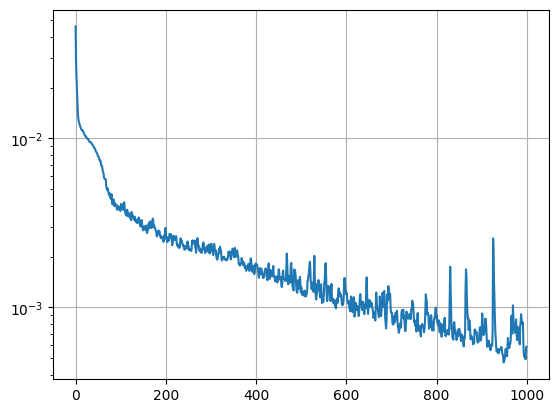

In [20]:
plt.semilogy(loss)
plt.grid()

In [21]:
n = 500
t = np.linspace(t0, tfinal, n)

A_data = np.random.uniform(-1.0, 1.0, size=(1,))
F_data = np.random.uniform(-1.0, 1.0, size=(1,))
G_data = np.random.uniform(-1.0, 1.0, size=(1,))
E_data = (1/4)*((A_data**2/l**2) + (F_data**2/k**2) + (2*(G_data**2)/(k**2 + l**2)))
V_data = (1/2)*(A_data**2 + F_data**2 + 2*(G_data**2))

init_data_rk = np.column_stack((A_data, F_data, G_data))
init_data_rk = np.squeeze(init_data_rk)

init_data_model = np.column_stack((A_data, F_data, G_data, E_data, V_data))
init_data_model = np.squeeze(init_data_model)
print(init_data_model.shape)

z = np.repeat(np.expand_dims(init_data_model, axis=0), len(t), axis=0)
print(z.shape)

(5,)
(500, 5)


In [22]:
sol_rk = odeint(Lorenz1960, init_data_rk, t)
A_rk, F_rk, G_rk = sol_rk[:,0], sol_rk[:,1], sol_rk[:,2]
E_rk = (1/4)*((A_rk**2/l**2) + (F_rk**2/k**2) + (2*(G_rk**2)/(k**2 + l**2)))
V_rk = (1/2)*(A_rk**2 + F_rk**2 + 2*(G_rk**2))

In [23]:
A_model = jax.vmap(var_model, [0, 0, None, None])(t, z, 0, params)
F_model = jax.vmap(var_model, [0, 0, None, None])(t, z, 1, params)
G_model = jax.vmap(var_model, [0, 0, None, None])(t, z, 2, params)
E_model = (1/4)*((A_model**2/l**2) + (F_model**2/k**2) + (2*(G_model**2)/(k**2 + l**2)))
V_model = (1/2)*(A_model**2 + F_model**2 + 2*(G_model**2))

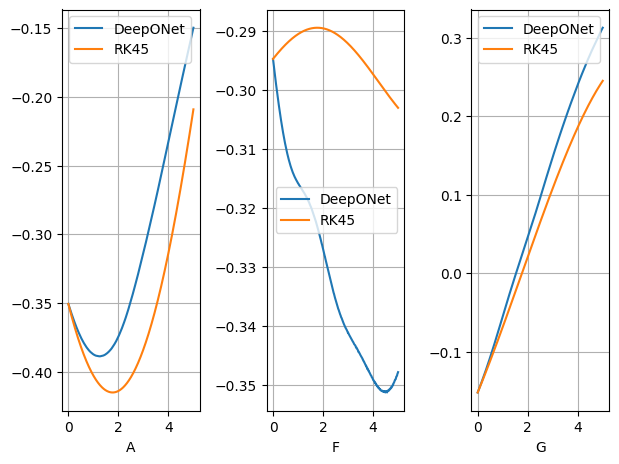

In [24]:
fig = plt.figure()

plt.subplot(1, 3, 1)
plt.tight_layout()
plt.plot(t, A_model)
plt.plot(t, A_rk)
plt.xlabel("A")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(1, 3, 2)
plt.tight_layout()
plt.plot(t, F_model)
plt.plot(t, F_rk)
plt.xlabel("F")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(1, 3, 3)
plt.tight_layout()
plt.plot(t, G_model)
plt.plot(t, G_rk)
plt.xlabel("G")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.show()

In [25]:
AFG_vals = jnp.column_stack((A_model, F_model, G_model))
E_vals = z[:, 3:4]
V_vals = z[:, 4:]

print(type(AFG_vals), AFG_vals.shape)
print(type(E_vals), E_vals.shape)
print(type(V_vals), V_vals.shape)

<class 'jaxlib.xla_extension.ArrayImpl'> (500, 3)
<class 'numpy.ndarray'> (500, 1)
<class 'numpy.ndarray'> (500, 1)


In [26]:
def obj_function_E(x, E_0) :

    A, F, G = x
    E = (0.25)*((A**2/l**2) + (F**2/k**2) + (2.*(G**2)/(k**2 + l**2)))
    E_err = (E-E_0)**2

    return E_err[0]


def obj_function_V(x, V_0) :
    
    A, F, G = x
    V = (1/2)*(A**2 + F**2 + 2*(G**2))
    V_err = (V-V_0)**2

    return V_err[0]

def obj_function_E_V(x, E_0, V_0) :

    factor = E_0/V_0
    factor = 1.0
    
    # factor = jnp.rint(jnp.log10(E_0/V_0))
    
    A, F, G = x
    E = (0.25)*((A**2/l**2) + (F**2/k**2) + (2.*(G**2)/(k**2 + l**2)))
    V = (1/2)*(A**2 + F**2 + 2*(G**2))

    E_err = (E-E_0)**2
    V_err = (V-V_0)**2

    err_total = E_err + factor*V_err

    return err_total[0]

In [27]:
def find_min_E(x, E_0):

    return minimize(obj_function_E, x, (E_0,), method='BFGS', tol = 1e-6)


def find_min_V(x, V_0):

    return minimize(obj_function_V, x, (V_0,), method='BFGS', tol = 1e-6)


def find_min_E_V(x, E_0, V_0):


    return minimize(obj_function_E_V, x, (E_0, V_0), method='BFGS', tol = 1e-7)

In [28]:
result_E_V = jax.vmap(find_min_E_V, (0, 0, 0), 0)(AFG_vals, E_vals, V_vals)
result_E_V = result_E_V.x

result_final = result_E_V

print(result_final.shape)

(500, 3)


In [29]:
print(AFG_vals.shape, E_vals.shape, V_vals.shape)

(500, 3) (500, 1) (500, 1)


In [30]:
A_final = result_final[:, 0]
F_final = result_final[:, 1]
G_final = result_final[:, 2]
E_final = (1/4)*((A_final**2/l**2) + (F_final**2/k**2) + (2*(G_final**2)/(k**2 + l**2)))
V_final = (1/2)*(A_final**2 + F_final**2 + 2*(G_final**2))

print(A_final.shape, F_final.shape, G_final.shape, E_final.shape, V_final.shape)

(500,) (500,) (500,) (500,) (500,)


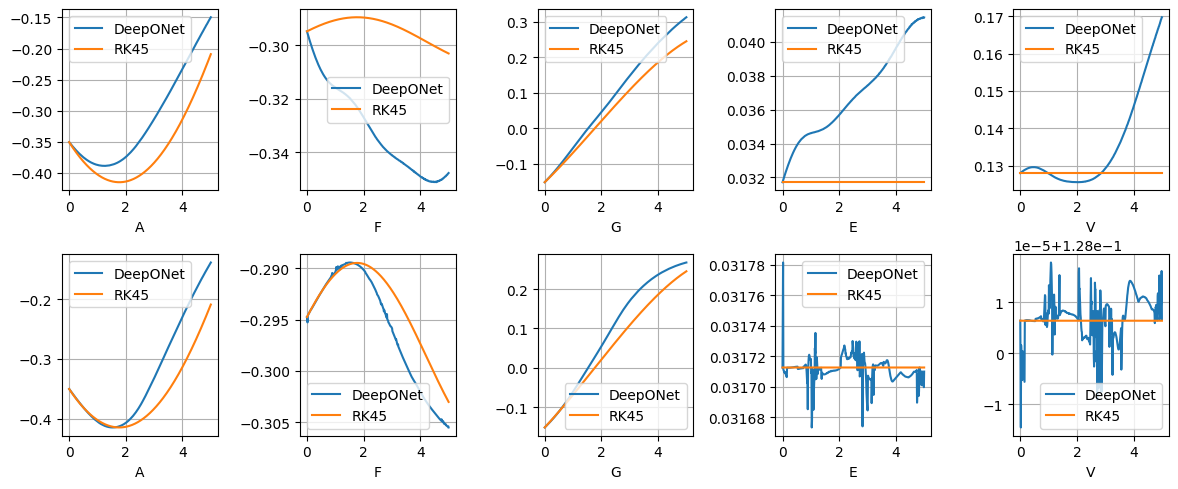

In [31]:
fig = plt.figure(figsize=(12, 5))

plt.subplot(2, 5, 1)
plt.tight_layout()
plt.plot(t, A_model)
plt.plot(t, A_rk)
plt.xlabel("A")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(2, 5, 2)
plt.tight_layout()
plt.plot(t, F_model)
plt.plot(t, F_rk)
plt.xlabel("F")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(2, 5, 3)
plt.tight_layout()
plt.plot(t, G_model)
plt.plot(t, G_rk)
plt.xlabel("G")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(2, 5, 4)
plt.tight_layout()
plt.plot(t, E_model)
plt.plot(t, E_rk)
plt.xlabel("E")
plt.grid()
plt.legend(['DeepONet','RK45'])


plt.subplot(2, 5, 5)
plt.tight_layout()
plt.plot(t, V_model)
plt.plot(t, V_rk)
plt.xlabel("V")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(2, 5, 6)
plt.tight_layout()
plt.plot(t, A_final)
plt.plot(t, A_rk)
plt.xlabel("A")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(2, 5, 7)
plt.tight_layout()
plt.plot(t, F_final)
plt.plot(t, F_rk)
plt.xlabel("F")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(2, 5, 8)
plt.tight_layout()
plt.plot(t, G_final)
plt.plot(t, G_rk)
plt.xlabel("G")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(2, 5, 9)
plt.tight_layout()
plt.plot(t, E_final)
plt.plot(t, E_rk)
plt.xlabel("E")
plt.grid()
plt.legend(['DeepONet','RK45'])


plt.subplot(2, 5, 10)
plt.tight_layout()
plt.plot(t, V_final)
plt.plot(t, V_rk)
plt.xlabel("V")
plt.grid()
plt.legend(['DeepONet','RK45'])


plt.show()

In [18]:
@jax.jit
def func_D(x, A_init, F_init, G_init, E_0, V_0) :

    # factor = E_0/V_0
    factor = 1.0
    
    A = x[0]
    F = x[1]
    G = x[2]
    
    E = (0.25)*((A**2/l**2) + (F**2/k**2) + (2.*(G**2)/(k**2 + l**2)))
    V = (1/2)*(A**2 + F**2 + 2*(G**2))

    D = 0.0*((A - A_init)**2 + (F - F_init)**2 + (G - G_init)**2) + (E - E_0)**2 + factor*(V - V_0)**2

    D_arr = jnp.array([D])
    D_arr = jnp.reshape(D_arr, (-1,))

    return D_arr[0]

In [19]:
@jax.jit
def LBFGS(x, E_0, V_0) :

    max_iter = 10
    min_tol = 1e-6

    x_0 = jnp.copy(x)
    x_0 = 0.95*x_0

    A_init = x[0]
    F_init = x[1]
    G_init = x[2]

    solver = jaxopt.LBFGS(func_D, maxiter = max_iter, tol = min_tol)
    result = solver.run(x_0, A_init, F_init, G_init, E_0, V_0)
    result = result.params

    A = result[0]
    F = result[1]
    G = result[2]

    return A, F, G

    

In [20]:
AFG_test = jnp.array([[0.56], [-0.2], [0.78]])
E_0_test = jnp.array([[1.52]])
V_0_test = jnp.array([[0.67]])

A, F, G = LBFGS(AFG_test, E_0_test, V_0_test)
print(A, F, G)

grad_func = jax.grad(LBFGS)
print(grad_func(AFG_test, E_0_test, V_0_test))

[-0.00597446] [-1.5434692] [0.01364638]


TypeError: Gradient only defined for scalar-output functions. Output was (Array([-0.00597446], dtype=float32), Array([-1.5434692], dtype=float32), Array([0.01364638], dtype=float32)).

In [35]:
# AFG_test = jnp.array([0.56, -0.2, 0.78])
# E_0_test = jnp.array([1.52])
# V_0_test = jnp.array([0.67])


# result = minimize(obj_function_E_V, AFG_test, (E_0_test, V_0_test), method='LBFGS', tol = 1-6)
# print(result.x)

In [36]:
@jax.jit
def find_min_E_V(AFG_list, E_0, V_0) :

    A = AFG_list[0]
    F = AFG_list[1]
    G = AFG_list[2]

    x = jnp.column_stack((A, F, G))  

    return jax.vmap(LBFGS, (0, 0, 0), 0)(x, E_0, V_0)

In [37]:
class ClosestPoint(nn.Module):

    E_0: float
    V_0: float
    
    @nn.compact
    def __call__(self, inputs):
    
        A, F, G = find_min_E_V(inputs, self.E_0, self.V_0)
    
        return A, F, G

In [38]:
class CDeepONet(nn.Module):

  t0: float
  tfinal: float
  layers: int
  units: int

  @nn.compact
  def __call__(self, t, u):

    if u.ndim == 1:
      u = jnp.reshape(u, (1,-1))

    A_0 = u[:,:1]
    F_0 = u[:,1:2]
    G_0 = u[:,2:3]
    E_0 = u[:,3:4]
    V_0 = u[:,4:]


    u = u[:,:3]

    t = jnp.reshape(t, (-1,1))

    b = Normalize(self.t0, self.tfinal)(t)


    trunk_net = MLP(self.layers, self.units)(b)
    branch_net = MLP(self.layers, self.units)(u)

    A_tr = trunk_net[:,:self.units]
    F_tr = trunk_net[:,self.units:2*self.units]
    G_tr = trunk_net[:,2*self.units:]
    # E_tr = trunk_net[:,3*self.units:4*self.units]
    # V_tr = trunk_net[:,4*self.units:]

    A_br = branch_net[:,:self.units]
    F_br = branch_net[:,self.units:2*self.units]
    G_br = branch_net[:,2*self.units:]
    # E_br = branch_net[:,3*self.units:4*self.units]
    # V_br = branch_net[:,4*self.units:]

    A = CombineBranches()(A_tr, A_br)
    F = CombineBranches()(F_tr, F_br)
    G = CombineBranches()(G_tr, G_br)

    A = HardConstraint(self.t0, self.tfinal, A_0)([t, A])
    F = HardConstraint(self.t0, self.tfinal, F_0)([t, F])
    G = HardConstraint(self.t0, self.tfinal, G_0)([t, G])

    A, F, G = ClosestPoint(E_0, V_0)([A, F, G])
      
    A = jnp.reshape(A, (-1,))
    F = jnp.reshape(F, (-1,))
    G = jnp.reshape(G, (-1,))

    return A, F, G

In [39]:
@partial(jax.jit, static_argnums=(2,))
def Cvar_model(t, z, component, params):
  return Cdeeponet.apply(params, t, z)[component][0]

@partial(jax.jit, static_argnums=(2,))
def Cvar(t, z, component, params):
  return jax.vmap(Cvar_model, [0, 0, None, None])(t, z, component, params)

@partial(jax.jit, static_argnums=(2,))
def Cvar_t(t, z, component, params):
  return jax.vmap(jax.grad(Cvar_model, 0), [0, 0, None, None])(t, z, component, params)

@jax.jit
def Closs(params, t, z):
    
    A_t_loss_w = 1.0
    F_t_loss_w = 1.0
    G_t_loss_w = 1.0
    
    diff_loss_w = 1.0
    E_loss_w = 0.0
    V_loss_w = 0.0
    
    E_0_val = z[:, -2]
    V_0_val = z[:, -1]
    
    A_val = Cvar(t, z, 0, params)
    F_val = Cvar(t, z, 1, params)
    G_val = Cvar(t, z, 2, params)
    
    
    E_val = (0.25)*((A_val**2/l**2) + (F_val**2/k**2) + (2.*(G_val**2)/(k**2 + l**2)))
    E_loss = E_val - E_0_val
    E_loss = jnp.square(E_loss)
    E_loss = jnp.mean(E_loss)
    
    
    V_val = (0.5)*(A_val**2 + F_val**2 + 2*(G_val**2))
    V_loss = V_val - V_0_val
    V_loss = jnp.square(V_loss)
    V_loss = jnp.mean(V_loss)
    
    
    A_t_val = Cvar_t(t, z, 0, params)  
    F_t_val = Cvar_t(t, z, 1, params)
    G_t_val = Cvar_t(t, z, 2, params)

    # print("AFG_T VALS", A_t_val, F_t_val, G_t_val)
 
    
    A_t_loss = A_t_val + (1./(k**2) - 1./(k**2 + l**2))*(k * l * F_val * G_val)
    A_t_loss = jnp.square(A_t_loss)
    A_t_loss = jnp.mean(A_t_loss)
    
    F_t_loss = F_t_val - (1./(l**2) - 1./(k**2 + l**2))*(k * l * A_val * G_val)
    F_t_loss = jnp.square(F_t_loss)
    F_t_loss = jnp.mean(F_t_loss)
    
    G_t_loss = G_t_val + (0.25)*(1./(l**2) - 1./(k**2))*(k * l * A_val * F_val)
    G_t_loss = jnp.square(G_t_loss)
    G_t_loss = jnp.mean(G_t_loss)
    
    diff_loss = A_t_loss_w*A_t_loss + F_t_loss_w*F_t_loss + G_t_loss_w*G_t_loss
    
    final_loss = diff_loss_w*diff_loss + E_loss_w*E_loss + V_loss_w*V_loss

    return final_loss

@jax.jit
def Ctrain_step(params, pdes, z):
  t = pdes[:,0]
    
  return jax.value_and_grad(Closs)(params, t, z)

@partial(jax.jit, static_argnums=(3,))
def Coptimize(grads, opt_state, params, optimizer_update):
  updates, opt_state = optimizer_update(grads, opt_state, params)
  params = optax.apply_updates(params, updates)
  return params, opt_state

In [40]:
def Ctrain_network(params, des, sensors, epochs=100):

  N = de_points.shape[0]

  nr_batches = 10
  batch_size = len(des)//nr_batches

  print("batch size:", batch_size)

  lr = 1e-3
  optimizer = optax.adam(lr)
  opt_state = optimizer.init(params)

  ds_z = tf.data.Dataset.from_tensor_slices(sensors)
  ds_de = tf.data.Dataset.from_tensor_slices(des)

  ds = tf.data.Dataset.zip((ds_de, ds_z))
  ds = ds.shuffle(N).batch(batch_size)

  epoch_loss = np.zeros(epochs)

  batch_no = 0

  for i in range(epochs):

    for (des_batch, z_batch) in ds:

      loss, grads = Ctrain_step(params, des_batch.numpy(), z_batch.numpy())
      params, opt_state = Coptimize(grads, opt_state, params, optimizer.update)
        
      epoch_loss[i] += loss

    epoch_loss[i] /= batch_size

    if i % 1  == 0:
      print(f'Loss in epoch {i}: {epoch_loss[i]}')

  return params, epoch_loss

In [41]:
Cdeeponet = CDeepONet(t0, tfinal, layers=4, units=40)

t_init = jnp.full((10, ), 1.0)
u_init = jnp.full((10, 5), 1.0)

Cparams = Cdeeponet.init(jax.random.PRNGKey(0), t_init, u_init)

In [42]:
Cparam_count = sum(x.size for x in jax.tree.leaves(Cparams))
print(Cparam_count)

16640


In [43]:
Cparams = copy.deepcopy(params)

In [44]:
epochs = 50
Cparams, Closs = Ctrain_network(Cparams, de_points, sensors, epochs)

batch size: 100
Loss in epoch 0: 0.02250039577484131
Loss in epoch 1: 0.02250039577484131
Loss in epoch 2: 0.02250039577484131
Loss in epoch 3: 0.02250039577484131
Loss in epoch 4: 0.02250039577484131
Loss in epoch 5: 0.02250039577484131
Loss in epoch 6: 0.02250039339065552
Loss in epoch 7: 0.02250039577484131
Loss in epoch 8: 0.02250039339065552
Loss in epoch 9: 0.02250039577484131
Loss in epoch 10: 0.02250039577484131
Loss in epoch 11: 0.02250039577484131
Loss in epoch 12: 0.02250039339065552
Loss in epoch 13: 0.02250039339065552
Loss in epoch 14: 0.02250039339065552
Loss in epoch 15: 0.02250039339065552
Loss in epoch 16: 0.02250039339065552
Loss in epoch 17: 0.02250039339065552
Loss in epoch 18: 0.02250039339065552
Loss in epoch 19: 0.02250039577484131
Loss in epoch 20: 0.02250039577484131
Loss in epoch 21: 0.02250039577484131
Loss in epoch 22: 0.02250039577484131
Loss in epoch 23: 0.02250039339065552
Loss in epoch 24: 0.02250039339065552
Loss in epoch 25: 0.02250039577484131
Loss i

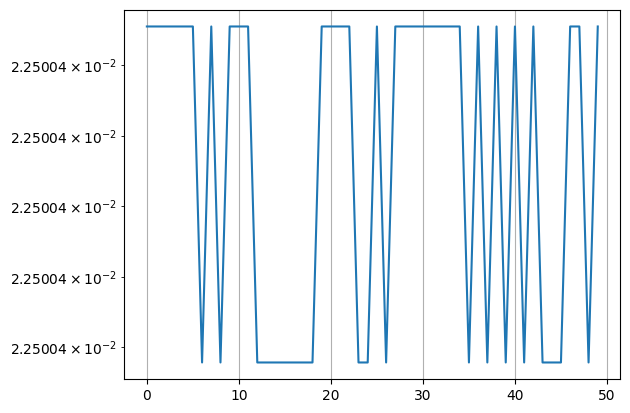

In [45]:
plt.semilogy(Closs)
plt.grid()

In [46]:
A = jax.vmap(Cvar_model, [0, 0, None, None])(t, z, 0, Cparams)
F = jax.vmap(Cvar_model, [0, 0, None, None])(t, z, 1, Cparams)
G = jax.vmap(Cvar_model, [0, 0, None, None])(t, z, 2, Cparams)
E = (1/4)*((A**2/l**2) + (F**2/k**2) + (2*(G**2)/(k**2 + l**2)))
V = (1/2)*(A**2 + F**2 + 2*(G**2))

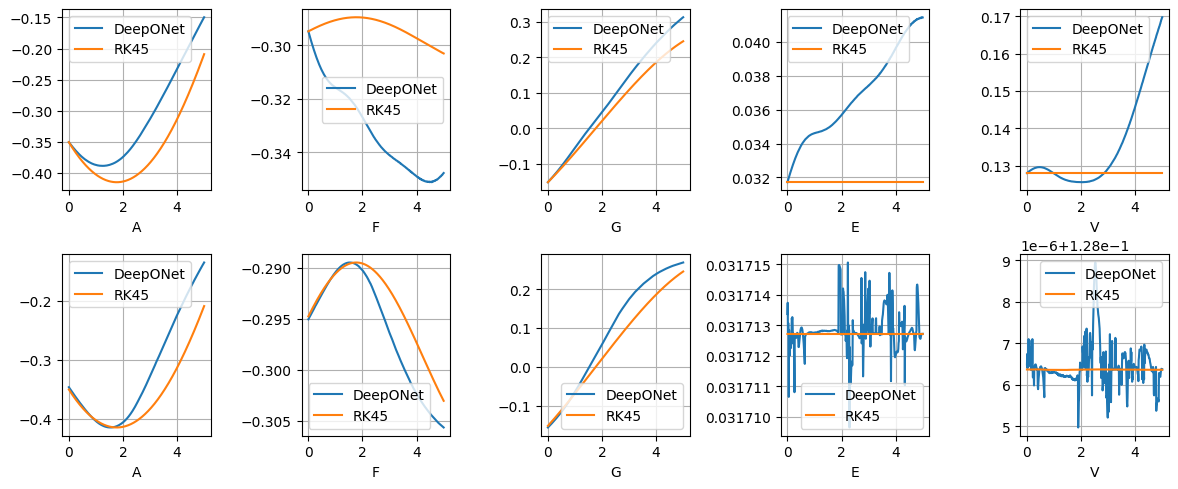

In [47]:
fig = plt.figure(figsize=(12, 5))

plt.subplot(2, 5, 1)
plt.tight_layout()
plt.plot(t, A_model)
plt.plot(t, A_rk)
plt.xlabel("A")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(2, 5, 2)
plt.tight_layout()
plt.plot(t, F_model)
plt.plot(t, F_rk)
plt.xlabel("F")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(2, 5, 3)
plt.tight_layout()
plt.plot(t, G_model)
plt.plot(t, G_rk)
plt.xlabel("G")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(2, 5, 4)
plt.tight_layout()
plt.plot(t, E_model)
plt.plot(t, E_rk)
plt.xlabel("E")
plt.grid()
plt.legend(['DeepONet','RK45'])


plt.subplot(2, 5, 5)
plt.tight_layout()
plt.plot(t, V_model)
plt.plot(t, V_rk)
plt.xlabel("V")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(2, 5, 6)
plt.tight_layout()
plt.plot(t, A)
plt.plot(t, A_rk)
plt.xlabel("A")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(2, 5, 7)
plt.tight_layout()
plt.plot(t, F)
plt.plot(t, F_rk)
plt.xlabel("F")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(2, 5, 8)
plt.tight_layout()
plt.plot(t, G)
plt.plot(t, G_rk)
plt.xlabel("G")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(2, 5, 9)
plt.tight_layout()
plt.plot(t, E)
plt.plot(t, E_rk)
plt.xlabel("E")
plt.grid()
plt.legend(['DeepONet','RK45'])


plt.subplot(2, 5, 10)
plt.tight_layout()
plt.plot(t, V)
plt.plot(t, V_rk)
plt.xlabel("V")
plt.grid()
plt.legend(['DeepONet','RK45'])


plt.show()
